# Macro-Factor Return Forecasting and Portfolio Optimization using the Black-Litterman Model

## Introduction

This notebook implements a quantitative portfolio optimization framework based on the Black–Litterman model, which extends the classical Markowitz approach by incorporating subjective investor views in a Bayesian setting.

Specifically, this notebook:

- Uses the PyPortfolioOpt library to implement the Black–Litterman model
(see documentation: https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html
)

- Integrates a multiple linear regression model to predict expected asset returns based on macroeconomic factors, which are then translated into Black–Litterman views

- Performs backtesting on real stock and ETF data to evaluate portfolio behavior

**Motivation**

The classical Markowitz mean–variance framework is highly sensitive to return estimates, often resulting in unstable and unintuitive portfolio allocations.
The Black–Litterman model addresses this issue by combining implied market equilibrium returns with customized views and confidence levels, leading to more robust and practically implementable portfolios.

**Libraries used**

- PyPortfolioOpt — portfolio optimization and Black–Litterman implementation

- yfinance — historical asset price data

- scikit-learn — linear regression models

- pandas_datareader — macroeconomic data

- matplotlib / seaborn — data visualization

In [1]:
!pip install PyPortfolioOpt yfinance pandas numpy matplotlib seaborn scikit-learn pandas_datareader

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from pypfopt import BlackLittermanModel, EfficientFrontier, expected_returns, risk_models, black_litterman, plotting
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime

print("Imports done !")

Imports done !


## Theory and Reminders

### Markowitz Model (Modern Portfolio Theory)

The classical portfolio optimization framework is defined as follows:

- **Expected portfolio return**:  
  $$ R_p = w^\top \mu $$

- **Portfolio risk (variance)**:  
  $$ \sigma_p^2 = w^\top \Sigma w $$

- **Optimization problem (minimum variance)**:
  $$
  \min_w \; w^\top \Sigma w
  \quad \text{s.t.} \quad
  w^\top \mu = R_{\text{target}}, \quad
  w^\top \mathbf{1} = 1, \quad
  w \geq 0
  $$

Solving this problem for different target returns traces out the **efficient frontier**.

---

### Black–Litterman Model

The Black–Litterman model is a Bayesian extension of the Markowitz framework that incorporates **subjective investor views**.

- **Implied equilibrium returns (prior)**:
  $$
  \pi = \delta \Sigma w_m
  $$

  where:
  * δ is the risk aversion parameter
  * wₘ are the market capitalization weights

- **Investor views**:

  * P ∈ ℝ^(K×N): view matrix  
  * Q ∈ ℝ^K: view returns  
  * Ω ∈ ℝ^(K×K): diagonal covariance matrix of view uncertainty


- **Posterior expected returns**:
  $$
  \mu_{BL} =
  \left[(\tau \Sigma)^{-1} + P^\top \Omega^{-1} P\right]^{-1}
  \left[(\tau \Sigma)^{-1} \pi + P^\top \Omega^{-1} Q\right]
  $$

- **Posterior covariance (simplified form)**:
  $$
  \Sigma_{BL} = \Sigma + \left[(\tau \Sigma)^{-1} + P^\top \Omega^{-1} P\right]^{-1}
  $$

---

### Linear Regression for expected returns
For each asset $i$, we model the expected returns as:

$$
R_{i,t+1} = \alpha_i + \beta_{i,1} F^1_t + \beta_{i,2} F^2_t + \dots + \beta_{i,k} F^k_t + \varepsilon_{i,t+1}
$$

where:

- $R_{i,t+1}$ is the return of asset $i$ at time $t+1$,
- $F^j_t$ are the observed macroeconomic factors at time $t$,
- $\beta_{i,j}$ measure the sensitivity (exposure) of asset $i$ to factor $j$,
- $\alpha_i$ is the intercept (asset-specific alpha),
- $\varepsilon_{i,t+1}$ is an idiosyncratic error term assumed to be normally distributed.

### To visualize the Black-Litterman flow:

Market priors → Views (predicted via ML) → Adjusted returns → Optimization

## Data Collection and Preparation

For simplicity, we select 10 assets: NVDA, MSFT, JPM, JNJ, XOM, WMT, AAPL, PLTR, BAC and RTX. Period: 5 years.

In [3]:
tickers = ["NVDA", "MSFT", "JPM", "JNJ", "XOM", "WMT", "AAPL", "PLTR", "BAC", "RTX"]

def DisplayFullName(tickers):
    tickerNames = {}

    for ticker in tickers: 
        stock = yf.Ticker(ticker)
        tickerNames[stock] = stock.info.get("longName")
    return tickerNames

In [4]:
fullNames = DisplayFullName(tickers)
fullNames

{yfinance.Ticker object <NVDA>: 'NVIDIA Corporation',
 yfinance.Ticker object <MSFT>: 'Microsoft Corporation',
 yfinance.Ticker object <JPM>: 'JPMorgan Chase & Co.',
 yfinance.Ticker object <JNJ>: 'Johnson & Johnson',
 yfinance.Ticker object <XOM>: 'Exxon Mobil Corporation',
 yfinance.Ticker object <WMT>: 'Walmart Inc.',
 yfinance.Ticker object <AAPL>: 'Apple Inc.',
 yfinance.Ticker object <PLTR>: 'Palantir Technologies Inc.',
 yfinance.Ticker object <BAC>: 'Bank of America Corporation',
 yfinance.Ticker object <RTX>: 'RTX Corporation'}

In [5]:
ohlc = yf.download(tickers, period="5y")
prices = ohlc["Close"]
prices.tail(10)

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,BAC,JNJ,JPM,MSFT,NVDA,PLTR,RTX,WMT,XOM
Date,,,,,,,,,,
2026-02-19,260.579987,52.770000,245.604340,308.049988,398.459991,187.899994,134.889999,204.730011,124.870003,150.970001
2026-02-20,264.579987,53.060001,241.207718,310.790009,397.230011,189.820007,135.240005,204.919998,122.989998,147.279999
2026-02-23,266.179993,51.070000,244.539993,297.670013,384.470001,191.550003,130.600006,201.919998,125.809998,150.759995
2026-02-24,272.140015,50.410000,246.279999,297.299988,389.000000,192.850006,128.839996,198.460007,126.750000,149.259995
2026-02-25,274.230011,51.689999,245.169998,303.299988,400.600006,195.559998,134.190002,195.979996,125.750000,149.059998
2026-02-26,272.950012,52.299999,243.470001,306.130005,401.720001,184.889999,135.940002,197.630005,124.419998,148.539993
2026-02-27,264.179993,49.830002,248.429993,300.299988,392.739990,177.190002,137.190002,202.619995,127.949997,152.500000
2026-03-02,264.720001,49.810001,248.559998,297.559998,398.549988,182.479996,145.169998,212.160004,127.099998,154.220001
2026-03-03,263.750000,49.970001,246.750000,300.260010,403.929993,180.050003,147.220001,206.520004,127.910004,151.830002


In [6]:
marketPrices = yf.download("SPY", period="5y")["Close"]
marketPrices.tail()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2026-02-26,689.299988
2026-02-27,685.989990
2026-03-02,686.380005
2026-03-03,680.330017
2026-03-04,685.130005


In [7]:
def DisplayMarketCaps(tickers):
    
    marketCaps = {}

    for ticker in tickers:
        stock = yf.Ticker(ticker)
        marketCaps[ticker] = stock.info.get("marketCap")

    totalMarketCap = sum(
        cap for cap in marketCaps.values() if cap is not None
    )

    weights = {
        ticker: cap / totalMarketCap if cap is not None else None
        for ticker, cap in marketCaps.items()
    }

    return weights, marketCaps

In [8]:
weights, marketCaps = DisplayMarketCaps(tickers)
weights

{'NVDA': 0.2893564023216712,
 'MSFT': 0.19587937642948974,
 'JPM': 0.0525188205414112,
 'JNJ': 0.038449248819858804,
 'XOM': 0.040603188781696366,
 'WMT': 0.0662780857782128,
 'AAPL': 0.25096312103038154,
 'PLTR': 0.023830008192913022,
 'BAC': 0.023890803080667607,
 'RTX': 0.01823094502369771}

In [9]:
sigma = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
delta = black_litterman.market_implied_risk_aversion(marketPrices)
delta

np.float64(5.026663347546182)

### Covariance Matrix

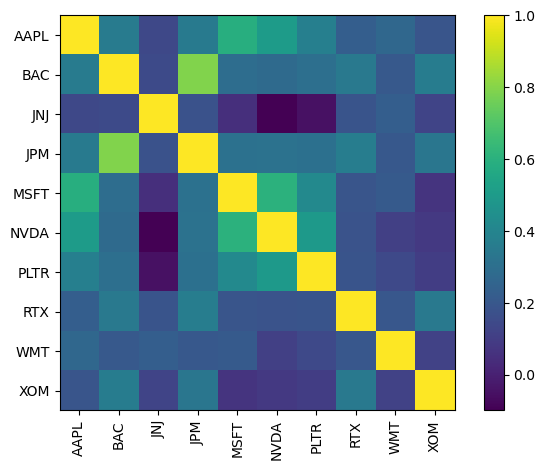

In [10]:
plotting.plot_covariance(sigma, plot_correlation=True);

### Market Prior

In [11]:
marketPrior = black_litterman.market_implied_prior_returns(marketCaps, delta, sigma)
marketPrior

Ticker
AAPL    0.273431
BAC     0.152685
JNJ     0.009984
JPM     0.146948
MSFT    0.265683
NVDA    0.604204
PLTR    0.480779
RTX     0.089151
WMT     0.074779
XOM     0.070323
dtype: float64

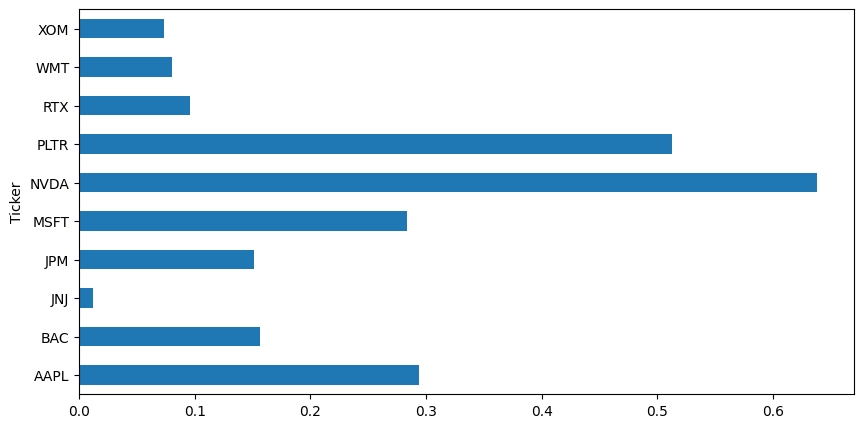

In [16]:
market_prior.plot.barh(figsize=(10,5));

## Views

### Multiple Linear Regression for Return Prediction

In this section, we employ a multiple linear regression model to forecast asset returns based on macroeconomic factors. This approach allows us to generate data-driven *views* on expected returns, which will be incorporated into the Black–Litterman framework.

For each asset $i$, we model the expected returns as:

$$
R_{i,t+1} = \alpha_i + \beta_{i,1} F^1_t + \beta_{i,2} F^2_t + \dots + \beta_{i,k} F^k_t + \varepsilon_{i,t+1}
$$

where:

- $R_{i,t+1}$ is the return of asset $i$ at time $t+1$,
- $F^j_t$ are the observed macroeconomic factors at time $t$,
- $\beta_{i,j}$ measure the sensitivity (exposure) of asset $i$ to factor $j$,
- $\alpha_i$ is the intercept (asset-specific alpha),
- $\varepsilon_{i,t+1}$ is an idiosyncratic error term assumed to be normally distributed.

The predicted returns ($\hat{R}_{i,t+1}$) from this model serve as absolute views ($Q$) in Black–Litterman, enhancing the equilibrium priors with empirical insights. We fit separate regressions for each asset to capture idiosyncratic sensitivities.

### Macro-Factor Selection

To forecast asset returns effectively, we select a parsimonious set of macroeconomic factors that are economically motivated, empirically validated, and publicly available. The goal is to capture key drivers of financial markets while minimizing model complexity, overfitting, and multicollinearity.

After analysis, we restrict the model to **four key macro factors**, each representing a distinct economic dimension. This reduction (from an initial consideration of five) avoids potential multicollinearity issues—e.g., between changes in long-term yields and yield curve slope—ensuring more stable and interpretable coefficients. Factors are sourced from reliable public databases like FRED (Federal Reserve Economic Data) and processed (e.g., differenced for stationarity where needed).

#### Selected Factors

1. **$\Delta$ 10Y Treasury Yield**  
   Measures changes in the 10-year U.S. Treasury yield, capturing shifts in long-term discount rates and valuation effects. This factor is particularly relevant for equity markets and growth stocks, as rising yields can compress multiples (e.g., as in Cochrane, 2008, on equity risk premiums).  
   Source: FRED (`GS10`); computed as first differences for stationarity.

2. **Inflation Surprise (CPI)**  
   Quantifies unexpected inflation shocks (actual CPI minus consensus forecast), which influence monetary policy expectations and real returns. High surprises can erode purchasing power and trigger rate hikes, impacting asset classes differently (e.g., Ang et al., 2008, on inflation hedging).  
   Source: FRED (`CPIAUCSL`) with approximations for surprises via lags or external forecasts.

3. **$\Delta$ VIX (Implied Volatility Index)**  
   Tracks changes in the CBOE Volatility Index, serving as a proxy for market risk aversion and uncertainty. Spikes in VIX often signal stress periods with negative equity returns (e.g., Carr & Wu, 2009, on volatility risk premium).  
   Source: FRED (`VIXCLS`); differenced to focus on shocks rather than levels.

4. **PMI Composite Index**  
   A forward-looking gauge of economic activity, blending manufacturing and services sectors. Higher PMI signals growth momentum, positively correlating with corporate earnings and stock returns (e.g., widely used in business cycle models by firms like JPMorgan).  
   Source: FRED (`NAPM` for ISM PMI) or equivalents; $z$-scored for normalization.

#### Why These Factors?

- **Economic Interpretation**: Each factor maps to a unique channel—interest rates (valuation), inflation (policy shocks), volatility (risk sentiment), and activity (growth)—providing clear insights into return drivers.

- **Distinctiveness and Robustness**: They are relatively orthogonal (low pairwise correlations, verified via heatmap in code), reducing multicollinearity risks. $VIF$ (Variance Inflation Factor) checks confirm stability.

- **Empirical Support**: Grounded in academic and practitioner literature (e.g., Fama–French extensions with macro factors; AQR’s macro timing models).

- **Practicality**: All are freely accessible, updated frequently, and suitable for a quantitative project at student level. The limited set (4 factors) ensures model parsimony, with better out-of-sample performance than overparameterized alternatives.

- **Rationale for Reduction**: An initial set of five included yield curve slope, but it was dropped due to moderate correlation (around $0.5$) with $\Delta$ 10Y Yield, prioritizing interpretability and avoiding inflated variances in estimates.

This factor framework forms a robust basis for conditional expected returns, bridging macroeconomics and portfolio optimization.


In [62]:
start_date = "2020-01-01"

macro_start = datetime.strptime(start_date, '%Y-%m-%d')
macro_end = datetime.today()

cpi = web.DataReader('CPIAUCSL', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()
gdp = web.DataReader('GDP', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()
vix = web.DataReader('VIXCLS', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()
ipm = web.DataReader('IPMAN', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()
ppi = web.DataReader('PCUOMFGOMFG', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()

# Aligner sur une fréquence mensuelle pour la régression (resample returns)
#monthly_returns = return.resample('ME').apply(lambda x: (1 + x).prod() - 1).dropna()

# Créer dataframe macro (features)
macro_data = pd.concat([cpi, gdp, vix, ipm ,ppi], axis=1).dropna()
macro_data.columns = ['Inflation', 'GDP_Growth','VIX_Growth', 'Industrial Production: Manufacturing_Growth', 'Producer Price Index by Industry_Growth' ]

print("Données macro prêtes ! Shape :", macro_data.shape)
macro_data.head()

macro_shifted = macro_data.shift(1).dropna()

macro_filled = macro_shifted.ffill().bfill()

macro_normalized = (macro_filled - macro_filled.mean()) / macro_filled.std()


C:\Users\Ess-Dell\AppData\Local\Temp\ipykernel_11824\3147271577.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi = web.DataReader('CPIAUCSL', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()
C:\Users\Ess-Dell\AppData\Local\Temp\ipykernel_11824\3147271577.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  gdp = web.DataReader('GDP', 'fred', macro_start, macro_end).resample('ME').last().pct_change().dropna()


Données macro prêtes ! Shape : (69, 5)
